# Generate data from rate model

firing rates, LFP, behavior

run after filtering down the models using filter_models_multiload.ipynb (in 0_behavior/1_model_performance folder)

[7/1/26] UPDATE: 
- going to use delay=150
- going to use only the "precomputed" datasets now
- adding load-2 trials to the generated trial set

In [1]:
%matplotlib inline
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis')
import generate_rate_data_multiload as grdm
from matplotlib import pyplot as plt
import numpy as np
import os

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld


2026-07-01 14:55:55.835108: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-01 14:55:55.842849: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-01 14:55:55.851620: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-01 14:55:55.854255: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-01 14:55:55.861365: I tensorflow/core/platform/cpu_feature_guar

## delay=150

### functions

In [2]:
def visualize_dataset(trial_labels):
    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    
    # first plot is how many match/mismatch trials per load
    load_match_labels = np.unique(trial_labels[:,:2], axis=0)
    counts = [np.sum(np.all(trial_labels[:,:2] == lm, axis=1)) for lm in load_match_labels]
    axs[0].bar(range(len(load_match_labels)), counts)
    axs[0].set_xticks(range(len(load_match_labels)))
    axs[0].set_xticklabels([f"Load{lm[0]}, {'match' if lm[1] == 1 else 'mismatch'}" for lm in load_match_labels], rotation=90)
    axs[0].set_title("Number of trials per load and label")

    # second plot is stimulus presentation counts for load 1
    load1_idxs = np.where(trial_labels[:,0] == 1)[0]
    stims, counts = np.unique(trial_labels[load1_idxs, 2], return_counts=True)
    stims = stims.astype(int)  # ensure stims are integers for labeling
    axs[1].bar(stims, counts)
    axs[1].set_xticks(stims)
    axs[1].set_xticklabels([f"Stim {s}" for s in stims])
    axs[1].set_title("Stim counts for load 1")
    
    # third plot is stimulus presentation counts for load 2
    load2_idxs = np.where(trial_labels[:,0] == 2)[0]
    for i, position in enumerate([2, 3]):
        stims, counts = np.unique(trial_labels[load2_idxs, position], return_counts=True)
        axs[2].bar(i + np.arange(len(stims)) * 0.2, counts, width=0.2, label=[f"Stim {s}" for s in stims])
    axs[2].set_xticks([i + 0.1 for i in range(2)])
    axs[2].set_xticklabels([f"Position {p}" for p in range(2)])
    axs[2].legend()
    axs[2].set_title("Stim counts for load 2")
    
    # fourth plot is stimulus presentation counts for load 3
    # 3 ticks for load 3, one for each position, 4 smaller bars for each tick, one for each stimulus
    load3_idxs = np.where(trial_labels[:,0] == 3)[0]
    for i, position in enumerate([2, 3, 4]):
        stims, counts = np.unique(trial_labels[load3_idxs, position], return_counts=True)
        axs[3].bar(i + np.arange(len(stims)) * 0.2, counts, width=0.2, label=[f"Stim {s}" for s in stims])
    axs[3].set_xticks([i + 0.3 for i in range(3)])
    axs[3].set_xticklabels([f"Position {p}" for p in range(3)])
    axs[3].legend()
    axs[3].set_title("Stim counts for load 3")
    axs[3].set_xlabel("Position")
    
    # plt.tight_layout()
    plt.show()

In [3]:
from itertools import permutations
import random
from collections import Counter

def generate_sternberg_trialtypes_load3(stimuli, memory_set_size=3, shuffle=False, n_repeats=1, seed=None):
    """
    Generate a Sternberg block balanced on:
      - Match vs mismatch (50/50)
      - All ordered memory sequences (permutations, not combinations)
      - Serial position of match probe (each position probed once per sequence)
      - Stimulus identity as match and mismatch probe
    
    Block size: 2 * P(n,k) * k = 2 * 24 * 3 = 144 trials (for 4 stimuli, set size 3)
    Output shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]
                                           match: 1 = match, -1 = mismatch
    """
    if seed is not None:
        random.seed(seed)

    seqs = list(permutations(stimuli, memory_set_size))
    trial_type_all = []

    for _ in range(n_repeats):
        for seq in seqs:
            seq = list(seq)
            excluded = [x for x in stimuli if x not in seq]
            assert len(excluded) == 1
            mismatch_probe = excluded[0]

            for pos in range(memory_set_size):
                trial_type_all.append([memory_set_size,  1] + seq + [seq[pos]])        # match
                trial_type_all.append([memory_set_size, -1] + seq + [mismatch_probe])  # mismatch

    if shuffle:
        random.shuffle(trial_type_all)

    return np.array(trial_type_all)  # shape: (n_trials, 6)

In [4]:
def generate_sternberg_trialtypes_load1(stimuli, memory_set_size=1, shuffle=False, n_repeats=1, seed=None):
    """
    Generate a load-1 Sternberg block with all possible trial combinations, balanced on:
      - Match vs mismatch (50/50)
      - All ordered memory sequences (permutations of size 1)
      - All possible mismatch probes for each sequence

    For load 1: 
      - 4 unique match trials (each stimulus shown and probed once)
      - 12 unique mismatch trials (4 sequences x 3 excluded stimuli)
      - Each match trial repeated 3x to achieve 50/50 balance
      - Total: 24 trials per repeat

    Output shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]
                                            stim2, stim3 = NaN (unused at load 1)
                                            match: 1 = match, -1 = mismatch
    """
    if seed is not None:
        random.seed(seed)

    seqs = list(permutations(stimuli, memory_set_size))  # 4 single-element sequences
    trials = []

    for _ in range(n_repeats):
        for seq in seqs:
            seq = list(seq)
            excluded = [x for x in stimuli if x not in seq]  # 3 excluded stimuli

            # All 3 mismatch probes for this sequence
            for mismatch_probe in excluded:
                trials.append([memory_set_size,  1] + seq + [float('nan'), float('nan')] + [seq[0]])          # match (repeated 3x across excluded loop)
                trials.append([memory_set_size, -1] + seq + [float('nan'), float('nan')] + [mismatch_probe])  # mismatch

    if shuffle:
        random.shuffle(trials)

    return np.array(trials, dtype=float)  # shape: (n_trials, 6)

In [5]:
def generate_sternberg_trialtypes_load2(stimuli, memory_set_size=2, shuffle=False, n_repeats=1, seed=None):
    """
    Generate a load-2 Sternberg block with all possible trial combinations, balanced on:
      - Match vs mismatch (50/50)
      - All ordered memory sequences (permutations of size 2)
      - All serial positions as match probe (2 per sequence)
      - All possible mismatch probes for each sequence (2 per sequence)

    For load 2:
      - 24 unique match trials (12 sequences x 2 serial positions)
      - 24 unique mismatch trials (12 sequences x 2 excluded stimuli)
      - Total: 48 trials per repeat

    Output shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]
                                            stim3 = NaN (unused at load 2)
                                            match: 1 = match, -1 = mismatch
    """
    if seed is not None:
        random.seed(seed)

    seqs = list(permutations(stimuli, memory_set_size))  # 12 ordered sequences
    trials = []

    for _ in range(n_repeats):
        for seq in seqs:
            seq = list(seq)
            excluded = [x for x in stimuli if x not in seq]  # 2 excluded stimuli

            # All 2 match probes (one per serial position)
            for pos in range(memory_set_size):
                trials.append([memory_set_size,  1] + seq + [float('nan')] + [seq[pos]])   # match

            # All 2 mismatch probes
            for mismatch_probe in excluded:
                trials.append([memory_set_size, -1] + seq + [float('nan')] + [mismatch_probe])  # mismatch

    if shuffle:
        random.shuffle(trials)

    return np.array(trials, dtype=float)  # shape: (n_trials, 6)

In [6]:
def generate_u_from_trialtypes(trial_type_all, settings):
    """
    Generate input u from trial_type_all.
    """
    n_trials = trial_type_all.shape[0]
    
    t_total = int(settings["T"])
    stim_on = int(settings["stim_on"])
    stim_dur = int(settings["stim_dur"])
    delay = int(settings["delay"])
    
    n_channels = 4
    u_all = np.zeros((n_trials, n_channels, settings["T"]), dtype=np.float32)  # shape: (n_trials, T, n_channels)
    
    for i_trial in range(n_trials):
        u = np.zeros((n_channels, t_total), dtype=np.float32)
        stim_chan_idx = trial_type_all[i_trial, 2:-1] # stim channels are in columns 2 to -1 (excluding last column which is probe)
        stim_chan_idx = stim_chan_idx[~np.isnan(stim_chan_idx)].astype(int) # remove possible nan's from stim_chan_idx (in case of lower load)
        probe_chan_idx = trial_type_all[i_trial, -1].astype(int)
        
        for i, i_chan in enumerate(stim_chan_idx):
            if i == 0:
                u[i_chan, stim_on:stim_on+stim_dur] = 1
                ending_idx = stim_on+stim_dur
            else: # 0 bc no separation btwn stimuli
                u[i_chan, ending_idx+0:ending_idx+stim_dur+0] = 1
                ending_idx = ending_idx+stim_dur+0
        
        u[probe_chan_idx, ending_idx+delay:ending_idx+delay+stim_dur] = 1
        u_all[i_trial] = u

    return u_all

Total number of trials: 960


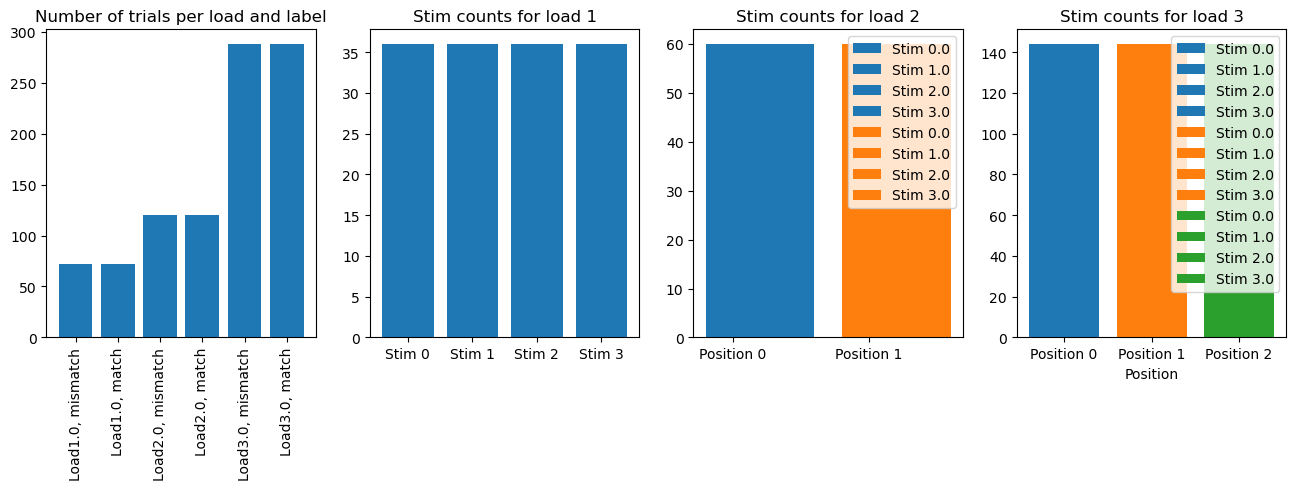

In [7]:
stimuli = [0, 1, 2, 3]
trial_type_load3 = generate_sternberg_trialtypes_load3(stimuli, shuffle=False, n_repeats=4, seed=42)
trial_type_load2 = generate_sternberg_trialtypes_load2(stimuli, shuffle=False, n_repeats=5, seed=42)
trial_type_load1 = generate_sternberg_trialtypes_load1(stimuli, shuffle=False, n_repeats=6, seed=42)

# stack
trial_type_all = np.vstack([trial_type_load3, trial_type_load2, trial_type_load1])
print(f"Total number of trials: {trial_type_all.shape[0]}")

visualize_dataset(trial_type_all)

### generate data

In [8]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

stims = [0, 1, 2, 3]
settings =  {
    "T": 450,
    "stim_on": 50,
    "stim_dur": 25,
    # "delay": 200,
    "delay": 150,
    "DeltaT": 1,
    "taus": 20,
    "fs": 200,
    "task": "sternberg",
    "load": 1,
}

trial_type_load3 = generate_sternberg_trialtypes_load3(stims, shuffle=False, n_repeats=3, seed=42)
trial_type_load2 = generate_sternberg_trialtypes_load2(stims, shuffle=False, n_repeats=5, seed=42)
trial_type_load1 = generate_sternberg_trialtypes_load1(stims, shuffle=False, n_repeats=6, seed=42)
trial_type_all = np.vstack([trial_type_load3, trial_type_load2, trial_type_load1])
u_all = generate_u_from_trialtypes(trial_type_all, settings)

for model_name in model_names:
    
    model_dir = os.path.join(all_models_dir, model_name)
    
    grdm.generate_data(
        model_dir="/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3",
        pattern="*N_1000*.mat",
        n_repetitions=3,          # used by balance_stims (unused)
        eval_amp_threshold=0.7,
        workers=1,
        backend="torch",
        device="cuda",
        overwrite=False,
        mode="precomputed",     # or "balance_match" / "balance_stims"
        output_tag="balanced123",
        n_trials=50,              # used by balance_match (unused)
        loads=[1, 3],             # used by balance_match (unused)
        include_models=[model_name],
        u_all = u_all,
        trial_type_all = trial_type_all
    )
        
# the saved data will just be called bhv_dict_delay150_precomputed_balanced123.pkl

Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901
neural filename: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901/neural_dict_delay150_precomputed_balanced123.pkl
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721
neural filename: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721/neural_dict_delay150_precomputed_balanced123.pkl
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000


/tmp/ipykernel_912676/1959176672.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([load1_perfs, load2_perfs, load3_perfs], widths=0.3, positions=x,


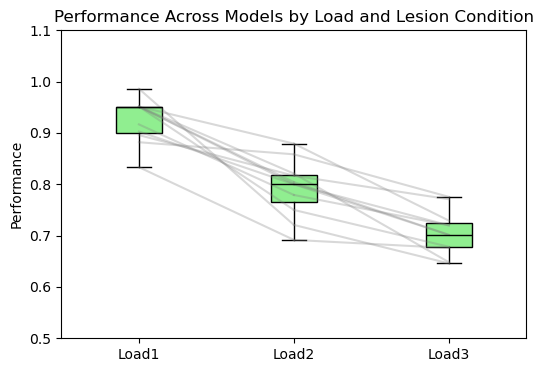

In [22]:
# plot summary boxplots with all models together

load1_perfs = np.zeros(len(model_names))  # columns: [control]
load2_perfs = np.zeros(len(model_names))  # columns: [control]
load3_perfs = np.zeros(len(model_names))  # columns: [control]

condn_phrase='delay'
condn_num=150

for i, model_name in enumerate(model_names):
    trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='precomputed_balanced123',
        all_models_dir=all_models_dir
    )
    
    # Control performance
    ctrl_trial_idxs_load1 = np.where((trial_labels_ctrl[:, 0] == 1))[0]
    load1_perfs[i] = np.mean(trial_perfs_ctrl[ctrl_trial_idxs_load1])
    ctrl_trial_idxs_load2 = np.where((trial_labels_ctrl[:, 0] == 2))[0]
    load2_perfs[i] = np.mean(trial_perfs_ctrl[ctrl_trial_idxs_load2])
    ctrl_trial_idxs_load3 = np.where((trial_labels_ctrl[:, 0] == 3))[0]
    load3_perfs[i] = np.mean(trial_perfs_ctrl[ctrl_trial_idxs_load3])
    
x_labels = ['Load1','Load2','Load3']
x = np.arange(len(x_labels))

plt.figure(figsize=(6,4))
plt.boxplot([load1_perfs, load2_perfs, load3_perfs], widths=0.3, positions=x,
            patch_artist=True, boxprops=dict(facecolor='Lightgreen', color='black'), 
            medianprops=dict(color='black'), labels=x_labels)

# draw gray lines
for i in range(len(model_names)):
    plt.plot([x[0], x[1]], [load1_perfs[i], load2_perfs[i]], color='gray', alpha=0.3)
    plt.plot([x[1], x[2]], [load2_perfs[i], load3_perfs[i]], color='gray', alpha=0.3)

plt.xticks(x, x_labels)
plt.ylabel('Performance')
plt.title('Performance Across Models by Load and Lesion Condition')
# plt.legend([plt.Rectangle((0,0),1,1,facecolor='yellow'), plt.Rectangle((0,0),1,1,facecolor='magenta')], 
#            ['Load 1', 'Load 3'], loc='upper right')
plt.ylim(0.5, 1.1)
plt.show()